In [ ]:
import csv
import json
from datetime import datetime

LIMITE_SUSPEITO = 10000.00

In [ ]:
def ler_transacoes(caminho):
    transacoes = []

    try:
        with open(caminho, mode="r", encoding="utf-8") as arquivo:
            leitor = csv.DictReader(arquivo)

            for linha in leitor:
                transacoes.append(linha)

    except FileNotFoundError:
        print("Arquivo não encontrado.")
        return []

    return transacoes

In [ ]:
def validar_transacao(linha):
    if not linha["id"] or not linha["id"].isdigit():
        return None

    if not linha["cliente_id"].strip():
        return None

    if linha["tipo"] not in ["credito", "debito"]:
        return None

    try:
        valor = float(linha["valor"])

        if valor <= 0:
            return None

    except ValueError:
        return None

    try:
        data = datetime.strptime(linha["data"], "%Y-%m-%d")

    except ValueError:
        return None

    transacao_limpa = {
        "id": int(linha["id"]),
        "data": data,
        "cliente_id": linha["cliente_id"],
        "tipo": linha["tipo"],
        "valor": valor,
        "descricao": linha["descricao"],
        "categoria": linha["categoria"]
    }

    return transacao_limpa

In [ ]:
def gerar_relatorio(transacoes):
    resumo_mensal = {}
    transacoes_suspeitas = []

    if not transacoes:
        return {}, [], None, None, 0

    for transacao in transacoes:
        mes = transacao["data"].strftime("%Y-%m")
        valor = transacao["valor"]

        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "soma_valores": 0.0,
                "maior_valor": valor,
                "menor_valor": valor
            }

        dados_mes = resumo_mensal[mes]

        dados_mes["quantidade"] += 1
        dados_mes["soma_valores"] += valor

        if transacao["tipo"] == "credito":
            dados_mes["total_credito"] += valor
        else:
            dados_mes["total_debito"] += valor

        if valor > dados_mes["maior_valor"]:
            dados_mes["maior_valor"] = valor

        if valor < dados_mes["menor_valor"]:
            dados_mes["menor_valor"] = valor

        if valor > LIMITE_SUSPEITO:
            transacoes_suspeitas.append(transacao)

    for mes in resumo_mensal:
        dados_mes = resumo_mensal[mes]

        dados_mes["saldo"] = (
            dados_mes["total_credito"] - dados_mes["total_debito"]
        )

        dados_mes["media"] = (
            dados_mes["soma_valores"] / dados_mes["quantidade"]
        )

        del dados_mes["soma_valores"]

    datas = [transacao["data"] for transacao in transacoes]

    data_mais_antiga = min(datas)
    data_mais_recente = max(datas)
    dias_periodo = (data_mais_recente - data_mais_antiga).days

    return (
        resumo_mensal,
        transacoes_suspeitas,
        data_mais_antiga,
        data_mais_recente,
        dias_periodo
    )

In [ ]:
def formatar_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def exibir_relatorio(
    resumo_mensal,
    transacoes_suspeitas,
    data_mais_antiga,
    data_mais_recente,
    dias_periodo,
    total_validas,
    total_invalidas
):
    print("\n===== RELATÓRIO FINANCEIRO =====")

    print(
        f"Período analisado: "
        f"{data_mais_antiga.strftime('%Y-%m-%d')} → "
        f"{data_mais_recente.strftime('%Y-%m-%d')}"
    )

    print(f"Dias no período: {dias_periodo}")
    print(f"Transações válidas: {total_validas}")
    print(f"Transações inválidas: {total_invalidas}")

    print("\n===== RELATÓRIO MENSAL =====")

    for mes in sorted(resumo_mensal):
        dados = resumo_mensal[mes]

        print(f"\nMês: {mes}")
        print(f"  Transações:    {dados['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(dados['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(dados['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(dados['saldo'])}")
        print(f"  Média:         {formatar_moeda(dados['media'])}")
        print(f"  Maior valor:   {formatar_moeda(dados['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(dados['menor_valor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")

    if transacoes_suspeitas:
        for transacao in transacoes_suspeitas:
            print(
                f"ID: {transacao['id']} | "
                f"Cliente: {transacao['cliente_id']} | "
                f"Data: {transacao['data'].strftime('%Y-%m-%d')} | "
                f"Valor: {formatar_moeda(transacao['valor'])}"
            )
    else:
        print("Nenhuma transação suspeita encontrada.")

In [ ]:
def salvar_json(
    resumo_mensal,
    transacoes_suspeitas,
    total_validas,
    total_invalidas
):
    suspeitas_json = []

    for transacao in transacoes_suspeitas:
        suspeitas_json.append({
            "id": transacao["id"],
            "cliente_id": transacao["cliente_id"],
            "data": transacao["data"].strftime("%Y-%m-%d"),
            "valor": transacao["valor"]
        })

    relatorio = {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "resumo_mensal": resumo_mensal,
        "transacoes_suspeitas": suspeitas_json
    }

    with open("relatorio.json", mode="w", encoding="utf-8") as arquivo:
        json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)

In [ ]:
dados_brutos = ler_transacoes("transacoes.csv")
dados_validos = []

for linha in dados_brutos:
    transacao = validar_transacao(linha)

    if transacao is not None:
        dados_validos.append(transacao)

total_lidas = len(dados_brutos)
total_validas = len(dados_validos)
total_invalidas = total_lidas - total_validas

print("===== RESUMO DA LIMPEZA =====")
print("Total de linhas lidas:", total_lidas)
print("Linhas válidas:", total_validas)
print("Linhas inválidas:", total_invalidas)

if dados_validos:
    (
        resumo_mensal,
        transacoes_suspeitas,
        data_mais_antiga,
        data_mais_recente,
        dias_periodo
    ) = gerar_relatorio(dados_validos)

    exibir_relatorio(
        resumo_mensal,
        transacoes_suspeitas,
        data_mais_antiga,
        data_mais_recente,
        dias_periodo,
        total_validas,
        total_invalidas
    )

    salvar_json(
        resumo_mensal,
        transacoes_suspeitas,
        total_validas,
        total_invalidas
    )

    print("\nArquivo relatorio.json gerado com sucesso.")

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 27
Linhas válidas: 20
Linhas inválidas: 7

===== RELATÓRIO FINANCEIRO =====
Período analisado: 2026-01-05 → 2026-04-18
Dias no período: 103
Transações válidas: 20
Transações inválidas: 7

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:    5
  Total crédito: R$ 16.000,00
  Total débito:  R$ 760,30
  Saldo:         R$ 15.239,70
  Média:         R$ 3.352,06
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações:    5
  Total crédito: R$ 22.200,00
  Total débito:  R$ 1.930,50
  Saldo:         R$ 20.269,50
  Média:         R$ 4.826,10
  Maior valor:   R$ 18.000,00
  Menor valor:   R$ 120,00

Mês: 2026-03
  Transações:    6
  Total crédito: R$ 12.700,00
  Total débito:  R$ 1.400,20
  Saldo:         R$ 11.299,80
  Média:         R$ 2.350,03
  Maior valor:   R$ 6.400,00
  Menor valor:   R$ 99,90

Mês: 2026-04
  Transações:    4
  Total crédito: R$ 3.900,00
  Total débito:  R$ 655,00
  Saldo:         R$ 3.

## Análises opcionais

As etapas a seguir apresentam uma análise alternativa dos dados utilizando Pandas e uma visualização dos resultados com Matplotlib.

In [ ]:
import pandas as pd

df = pd.read_csv("transacoes.csv")

df["id"] = pd.to_numeric(df["id"], errors="coerce")
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")

df_valido = df[
    df["id"].notna()
    & df["cliente_id"].notna()
    & df["data"].notna()
    & df["tipo"].isin(["credito", "debito"])
    & df["valor"].notna()
    & (df["valor"] > 0)
].copy()

df_valido["mes"] = df_valido["data"].dt.strftime("%Y-%m")

resumo_pandas = df_valido.groupby("mes").agg(
    quantidade=("id", "count"),
    media=("valor", "mean"),
    maior_valor=("valor", "max"),
    menor_valor=("valor", "min")
)

creditos = (
    df_valido[df_valido["tipo"] == "credito"]
    .groupby("mes")["valor"]
    .sum()
)

debitos = (
    df_valido[df_valido["tipo"] == "debito"]
    .groupby("mes")["valor"]
    .sum()
)

resumo_pandas["total_credito"] = creditos
resumo_pandas["total_debito"] = debitos

resumo_pandas["total_credito"] = resumo_pandas["total_credito"].fillna(0)
resumo_pandas["total_debito"] = resumo_pandas["total_debito"].fillna(0)

resumo_pandas["saldo"] = (
    resumo_pandas["total_credito"] - resumo_pandas["total_debito"]
)

resumo_pandas = resumo_pandas[
    [
        "quantidade",
        "total_credito",
        "total_debito",
        "saldo",
        "media",
        "maior_valor",
        "menor_valor"
    ]
]

print("===== ANÁLISE ALTERNATIVA COM PANDAS =====")
print(f"Transações válidas: {len(df_valido)}")
print(f"Transações inválidas: {len(df) - len(df_valido)}")

display(resumo_pandas.round(2))

===== ANÁLISE ALTERNATIVA COM PANDAS =====
Transações válidas: 20
Transações inválidas: 7


,quantidade,total_credito,total_debito,saldo,media,maior_valor,menor_valor
mes,,,,,,,
2026-01,5,16000.0,760.3,15239.7,3352.06,12500.0,89.9
2026-02,5,22200.0,1930.5,20269.5,4826.10,18000.0,120.0
2026-03,6,12700.0,1400.2,11299.8,2350.03,6400.0,99.9
2026-04,4,3900.0,655.0,3245.0,1138.75,3900.0,175.0


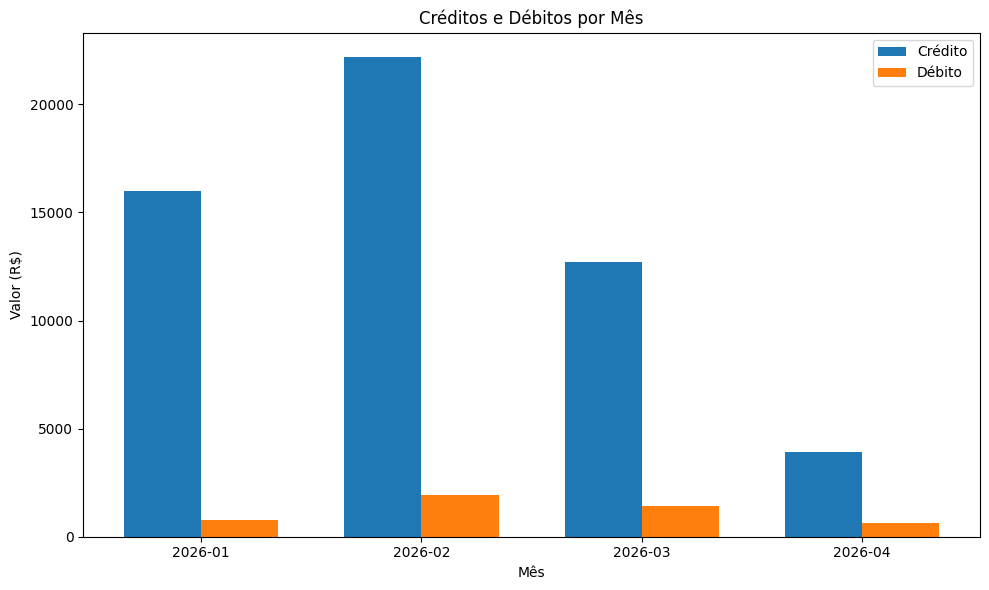

Arquivo grafico.png gerado com sucesso.


In [ ]:
import matplotlib.pyplot as plt

meses = resumo_pandas.index
creditos = resumo_pandas["total_credito"]
debitos = resumo_pandas["total_debito"]

x = range(len(meses))
largura = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - largura / 2 for i in x],
    creditos,
    width=largura,
    label="Crédito"
)

plt.bar(
    [i + largura / 2 for i in x],
    debitos,
    width=largura,
    label="Débito"
)

plt.title("Créditos e Débitos por Mês")
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.xticks(x, meses)
plt.legend()
plt.tight_layout()

plt.savefig("grafico.png")
plt.show()

print("Arquivo grafico.png gerado com sucesso.")